# Planes de Vida

Se realiza una exploración de datos previo a la construcción de la app Shiny de datos de censos

Por: Daning Montaño

# Librerías

In [1]:
library(ggplot2)
library(dplyr)
library(lubridate)
library(bslib)
source("Functions/plot_themes.R")
library(stringr)
library(plotly)
library(tidyr)
library(htmlwidgets)
library(dygraphs)
library(xts)
library(tidyverse)
library(googleVis)
library(treemapify)
library(scales)
library(tidytext)
library(igraph)
library(ggraph)
library(wordcloud)




Attaching package: ‘dplyr’

The following objects are masked from ‘package:stats’:

    filter, lag

The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Attaching package: ‘lubridate’

The following objects are masked from ‘package:base’:

    date, intersect, setdiff, union


Attaching package: ‘bslib’

The following object is masked from ‘package:utils’:

    page


Attaching package: ‘plotly’

The following object is masked from ‘package:ggplot2’:

    last_plot

The following object is masked from ‘package:stats’:

    filter

The following object is masked from ‘package:graphics’:

    layout



Warning message:
package ‘htmlwidgets’ was built under R version 4.4.3 
Warning message:
package ‘dygraphs’ was built under R version 4.4.3 


Loading required package: zoo

Attaching package: ‘zoo’

The following objects are masked from ‘package:base’:

    as.Date, as.Date.numeric


######################### Warning from 'xts' package ##########################
#                                                                             #
# The dplyr lag() function breaks how base R's lag() function is supposed to  #
# work, which breaks lag(my_xts). Calls to lag(my_xts) that you type or       #
# source() into this session won't work correctly.                            #
#                                                                             #
# Use stats::lag() to make sure you're not using dplyr::lag(), or you can add #
# conflictRules('dplyr', exclude = 'lag') to your .Rprofile to stop           #
# dplyr from breaking base R's lag() function.                                #
#                                                                             #
# Code in packages is not affected. It's protected by R's

Warning messages:
1: package ‘xts’ was built under R version 4.4.3 
2: package ‘zoo’ was built under R version 4.4.3 


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ forcats 1.0.0     ✔ readr   2.2.0
✔ purrr   1.0.2     ✔ tibble  3.3.1
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ plotly::filter() masks dplyr::filter(), stats::filter()
✖ xts::first()     masks dplyr::first()
✖ dplyr::lag()     masks stats::lag()
✖ xts::last()      masks dplyr::last()
ℹ Use the ]8;;http://conflicted.r-lib.org/conflicted package]8;; to force all conflicts to become errors


...

Warning message:
package ‘tidytext’ was built under R version 4.4.3 



Attaching package: ‘igraph’

The following objects are masked from ‘package:purrr’:

    compose, simplify

The following object is masked from ‘package:tibble’:

    as_data_frame

The following object is masked from ‘package:tidyr’:

    crossing

The following object is masked from ‘package:plotly’:

    groups

The following objects are masked from ‘package:lubridate’:

    %--%, union

The following objects are masked from ‘package:dplyr’:

    as_data_frame, groups, union

The following objects are masked from ‘package:stats’:

    decompose, spectrum

The following object is masked from ‘package:base’:

    union



Warning message:
package ‘igraph’ was built under R version 4.4.3 
Warning message:
package ‘ggraph’ was built under R version 4.4.3 


Loading required package: RColorBrewer


Warning message:
package ‘wordcloud’ was built under R version 4.4.3 


# Carga de datos

In [2]:
planesv_df_0 = read.csv("../Data/Planes_de_vida_general.csv")
planesv_df_0$Fecha = as.Date(planesv_df_0$Fecha, format = "%Y-%m-%d")
seguridad_alimentaria = read.csv("../Data/df_seguridad_alimentaria.csv")
entrega_insumos = read.csv("../Data/df_entrega_insumos.csv")
View(entrega_insumos)

# Análisis de datos

In [3]:
str(planesv_df_0)

'data.frame':	1021 obs. of  25 variables:
 $ X                   : int  0 1 2 3 4 5 6 7 8 9 ...
 $ X_id                : int  429831019 429862444 429863433 429863855 429864145 429864434 429864585 429865095 429865257 429865434 ...
 $ X_uuid              : chr  "12438341-75a5-4e7b-ae1d-f8c4299899f2" "5bdf03a9-8bfe-47f9-aaf0-e1006bdb08b4" "fe6b0d0c-47ac-4aea-96f4-2701625a4f17" "4ed7f627-f058-4eb1-b5c2-a98b3bea0d5e" ...
 $ X__version__        : chr  "vLpZmQcMYq6Tmax84J6AdP" "vyBpPtWiys8ZVBrdkNPo5E" "vyBpPtWiys8ZVBrdkNPo5E" "vyBpPtWiys8ZVBrdkNPo5E" ...
 $ X_submission_time   : chr  "2025-01-14T16:07:02" "2025-01-14T17:42:50" "2025-01-14T17:46:26" "2025-01-14T17:47:53" ...
 $ X_validation_status : chr  "Approved" "Approved" "Approved" "Approved" ...
 $ timestamp           : int  1736870832 1736876587 1736877076 1736877078 1736877080 1736877081 1736877083 1736877364 1736877366 1736877367 ...
 $ X_submitted_by      : chr  "monitoreo_pachamama" "monitoreo_pachamama" "monitoreo_pachamama" "monit

## Trabajo Comunidades

In [4]:
conteo_actividades <- planesv_df_0 %>%
  # Filtramos desde el 1 de diciembre de 2024 en adelante
  filter(Fecha >= as.Date("2025-01-01")) %>%
  group_by(Comunidad) %>%
  summarise(Total_registros = n()) %>%
  arrange(desc(Total_registros))

# Visualizar resultado
conteo_actividades

# A tibble: 4 × 2
  Comunidad      Total_registros
  <chr>                    <int>
1 Sharamentsa                143
2 Napurak                     53
3 Llanchamacocha               1
4 Shuinmamus                   1

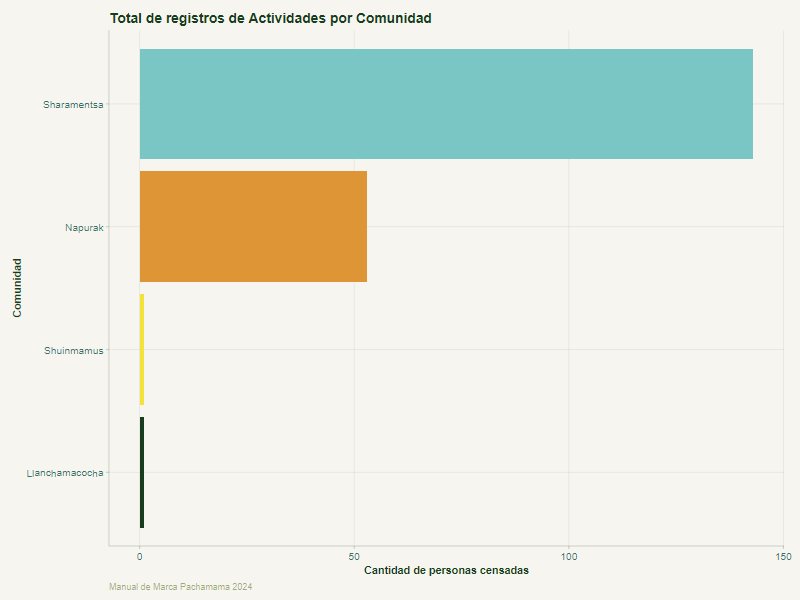

In [5]:
ggplot(conteo_actividades, aes(x = reorder(Comunidad, Total_registros), y = Total_registros, fill = Comunidad)) +
  geom_col(show.legend = FALSE) + # Las barras ya tienen el nombre abajo, no hace falta leyenda
  coord_flip() +                 # Giramos la gráfica para que los nombres de comunidades se lean bien
  scale_fill_pacha() +           # Colores oficiales de la Fundación
  labs(
    title = "Total de registros de Actividades por Comunidad",
    x = "Comunidad",
    y = "Cantidad de personas censadas",
    caption = "Manual de Marca Pachamama 2024"
  ) +
  theme_pachamama() +            # Tu tema personalizado
  theme(text = element_text(family = "sans")) # Evita errores si no tienes instalada la fuente Raleway

Cuando se hace una actividad y toma tiempo, el registro se hace cuando llega y se empieza la obra y se termina. Un solo registro, un solo informe del depsoito de como llegop la plata, que se hizo y que se obtuvo. Debe existir unb hash para cuando sale la plata y cuando se avaba la obra. Trazabilidad solicitud comunidad transferencia termino de actividad. 

Warning message:
Removed 10 rows containing missing values or values outside the scale range
(`geom_point()`). 


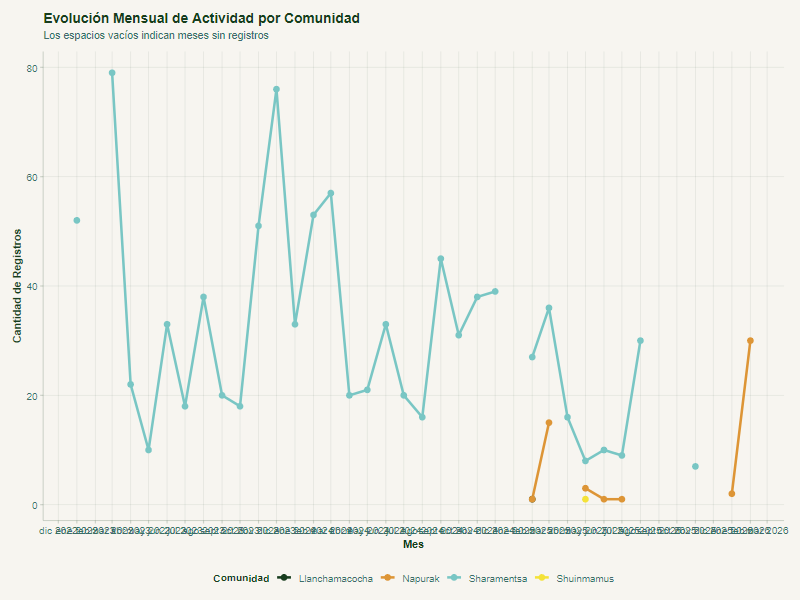

In [6]:

# 2. Procesar datos
serie_mensual <- planesv_df_0 %>%
  mutate(Mes = floor_date(as.Date(Fecha), "month")) %>%
  group_by(Mes, Comunidad) %>%
  summarise(Total_registros = n(), .groups = "drop") %>%
  
  # Paso clave: Completar los meses faltantes por cada Comunidad
  group_by(Comunidad) %>%
  complete(Mes = seq(min(Mes), max(Mes), by = "month")) %>%
  
  # Paso clave 2: No convertir a 0, dejar como NA para que la línea se corte
  # Si quieres que el punto desaparezca también, déjalo como NA.
  mutate(Total_registros = ifelse(Total_registros == 0, NA, Total_registros)) %>%
  ungroup()

# 3. Generar la gráfica
ggplot(serie_mensual, aes(x = Mes, y = Total_registros, color = Comunidad, group = Comunidad)) +
  # na.rm = FALSE es el default, esto causará el hueco en la línea
  geom_line(linewidth = 1.2) +
  geom_point(size = 2.5) +
  
  scale_color_pacha() + 
  
  scale_x_date(date_labels = "%b %Y", date_breaks = "1 month") +
  labs(
    title = "Evolución Mensual de Actividad por Comunidad",
    subtitle = "Los espacios vacíos indican meses sin registros",
    x = "Mes",
    y = "Cantidad de Registros",
    color = "Comunidad"
  ) +
  
  theme_pachamama() +
  theme(text = element_text(family = "sans"))

In [7]:
# Definir colores de la paleta para las líneas
colores_pacha <- as.character(PAL_CUAL[1:ncol(don_pacha)])
data_wide <- serie_mensual %>%
  # Pasamos de formato largo a ancho (una columna por comunidad)
  pivot_wider(names_from = Comunidad, values_from = Total_registros) %>%
  arrange(Mes)

# 2. Convertir a formato XTS (necesario para dygraphs)
# Usamos la columna Mes como el orden temporal
don_pacha <- xts(x = data_wide[,-1], order.by = data_wide$Mes)
plot_serie_tiempo <- dygraph(don_pacha, main = "Planes de vida por Comunidad") %>%
  # Configuración de estilo y colores institucionales
  dyOptions(
    labelsUTC = FALSE, 
    fillGraph = TRUE, 
    fillAlpha = 0.05, 
    drawGrid = TRUE, 
    gridLineColor = "#183d1e20", # Verde Hoja con transparencia
    colors = colores_pacha,
    strokeWidth = 2,
    axisLineColor = "#3c6d67",
    axisLabelFontSize = 12
  ) %>%
  # Selector de rango inferior (Range Selector)
  dyRangeSelector(height = 40, strokeColor = PAL$rio, fillColor = PAL$cielo) %>%
  # Línea vertical al pasar el mouse
  dyCrosshair(direction = "vertical") %>%
  # Resaltado al pasar el mouse
  dyHighlight(
    highlightCircleSize = 5, 
    highlightSeriesBackgroundAlpha = 0.3, 
    hideOnMouseOut = FALSE,
    highlightSeriesOpts = list(strokeWidth = 3)
  ) %>%
  # Promedio móvil (opcional, permite suavizar la línea en el gráfico)
  dyRoller(rollPeriod = 1) %>%
  # Títulos de ejes
  dyAxis("y", label = "Cantidad de Registros") %>%
  dyLegend(width = 400, show = "always", hideOnMouseOut = TRUE)

# Mostrar la gráfica


# Guardar como HTML interactivo
saveWidget(plot_serie_tiempo, "Plots/Serie_Temporal_Interactivo_Pachamama.html", selfcontained = TRUE)

: [1m[33mError[39m:[22m
[33m![39m object 'don_pacha' not found

## Trabajo monitores

In [ ]:
conteo_monitor = planesv_df_0  %>%
  filter(Fecha >= as.Date("2025-12-01"))%>%
  group_by(Monitor)%>%
  summarise(Total_registros = n())%>%
  arrange(-Total_registros)

conteo_monitor

# A tibble: 5 × 2
  Monitor                         Total_registros
  <chr>                                     <int>
1 Yampik_Tserem_Mainia_Pascualina              15
2 Tserem_Naranjas_Shakaim_Claudio              13
3 Claudio Tserem                                2
4 Claudio Tserem.                               1
5 Mukucham Tiriats                              1

## Actividades

In [ ]:
conteo_actividades = planesv_df_0  %>%
  filter(Fecha >= as.Date("2022-12-01"))%>%
  group_by(Comunidad, Actividad_monitorear, Tipo_accion )%>%
  summarise(Total_registros = n())%>%
  arrange(Comunidad)

conteo_actividades

`summarise()` has grouped output by 'Comunidad', 'Actividad_monitorear'. You
can override using the `.groups` argument.


# A tibble: 19 × 4
# Groups:   Comunidad, Actividad_monitorear [10]
   Comunidad      Actividad_monitorear   Tipo_accion           Total_registros
   <chr>          <chr>                  <chr>                           <int>
 1 Llanchamacocha Actividades economicas Entrega_de_insumos                  1
 2 Napurak        Actividades economicas Construcción                        2
 3 Napurak        Actividades economicas Otro                                1
 4 Napurak        Educación              Capacitacion_talleres               2
 5 Napurak        Salud                  Entrega_de_insumos                  1
 6 Napurak        Seguridad alimentaria  Entrega_de_insumos                 47
 7 Sharamentsa    Educación              Construcción                        1
 8 Sharamentsa    Educación              Otro                                1
 9 Sharamentsa    Otro                   Capacitacion_talleres               1
10 Sharamentsa    Otro                   Inspección            

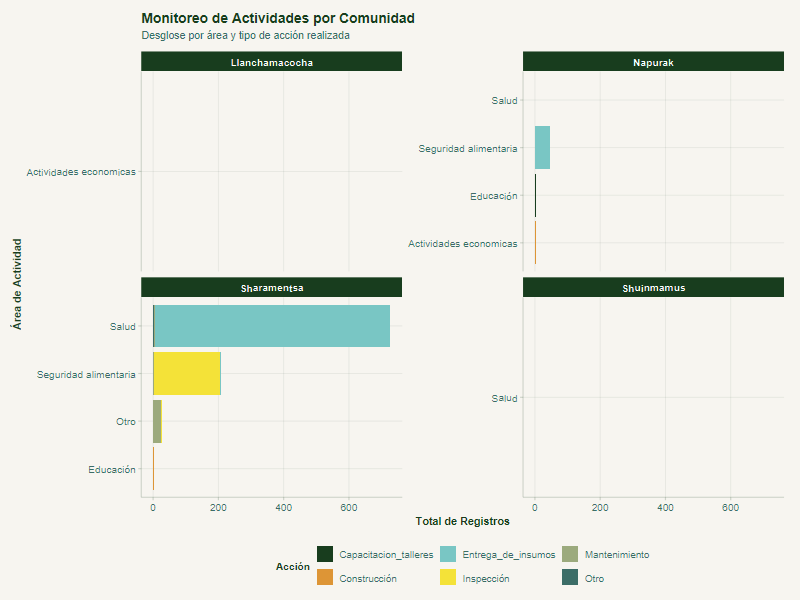

In [ ]:
ggplot(conteo_actividades, aes(x = reorder(Actividad_monitorear, Total_registros), 
                               y = Total_registros, 
                               fill = Tipo_accion)) +
  geom_col() +
  coord_flip() +
  # Dividimos por Comunidad para que no se mezcle todo
  facet_wrap(~Comunidad, scales = "free_y") +
  scale_fill_manual(values = PAL_CUAL) +
  labs(
    title = "Monitoreo de Actividades por Comunidad",
    subtitle = "Desglose por área y tipo de acción realizada",
    x = "Área de Actividad",
    y = "Total de Registros",
    fill = "Acción"
  ) +
  theme_pachamama() +
  theme(text = element_text(family = "sans"))

In [ ]:
# 1. Transformar datos para Sankey (Flujo de 2 niveles)
flujo_1 <- conteo_actividades %>%
  group_by(Comunidad, Actividad_monitorear) %>%
  summarise(Weight = sum(Total_registros), .groups = "drop") %>%
  rename(From = Comunidad, To = Actividad_monitorear)

flujo_2 <- conteo_actividades %>%
  group_by(Actividad_monitorear, Tipo_accion) %>%
  summarise(Weight = sum(Total_registros), .groups = "drop") %>%
  rename(From = Actividad_monitorear, To = Tipo_accion)

# Unir los dos flujos
datos_sankey <- bind_rows(flujo_1, flujo_2)

# 2. Configurar colores de la Fundación para GoogleVis
# Usamos los códigos hexadecimales de tu paleta
colores_js <- paste0("['", paste(PAL_CUAL, collapse = "', '"), "']")

opts_sankey <- list(
  sankey = paste0("{
    node: { 
      colors: ", colores_js, ",
      label: { fontName: 'sans-serif', fontSize: 12, color: '", PAL$hoja, "' },
      interactivity: true
    },
    link: { 
      colorMode: 'gradient',
      colors: ", colores_js, "
    }
  }")
)

# 3. Generar el Plot de Sankey
sankey_pacha <- gvisSankey(datos_sankey, 
                           from = "De", 
                           to = "A", 
                           weight = "N. actividades",
                           options = opts_sankey)

# 4. Mostrar el gráfico (se abrirá en tu navegador)
plot(sankey_pacha)

In [ ]:
View(datos_sankey)

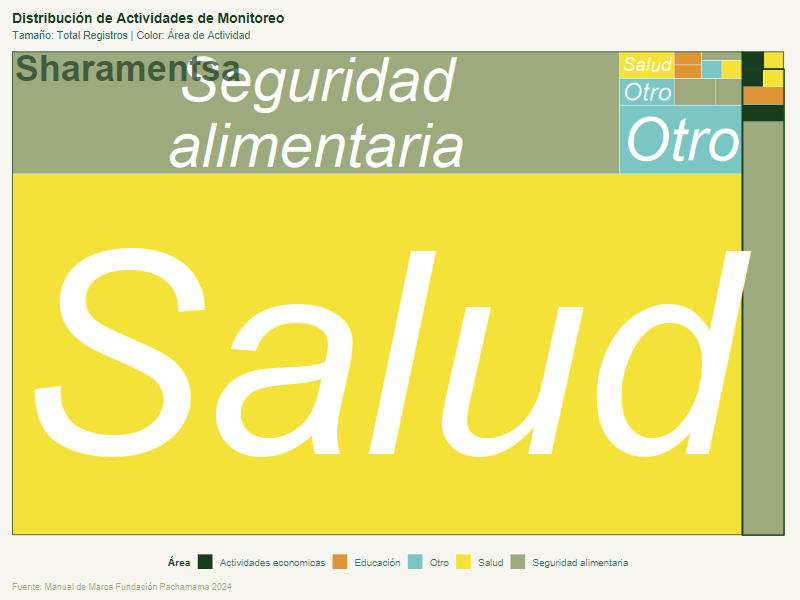

In [ ]:
# Generar el TreeMap
ggplot(conteo_actividades, aes(area = Total_registros, 
  fill = Actividad_monitorear, # Color por Actividad
  label = Actividad_monitorear, 
  subgroup = Comunidad)) +      # Agrupado por Comunidad
# Dibujar los rectángulos principales
geom_treemap(color = "white", size = 0.5) +

# Dibujar los bordes de las Comunidades (subgrupos)
geom_treemap_subgroup_border(color = PAL$hoja, size = 2) +

# Añadir etiquetas de texto
geom_treemap_text(color = "white", place = "centre", grow = TRUE, reflow = TRUE,
fontface = "italic", min.size = 8) +

# Títulos de las Comunidades (subgrupos)
geom_treemap_subgroup_text(place = "topleft", grow = FALSE, alpha = 0.7, color = PAL$hoja,
fontface = "bold", min.size = 10) +

# Colores institucionales y tema
scale_fill_manual(values = PAL_CUAL) +
labs(title = "Distribución de Actividades de Monitoreo",
subtitle = "Tamaño: Total Registros | Color: Área de Actividad",
fill = "Área",
caption = "Fuente: Manual de Marca Fundación Pachamama 2024") +

theme_pachamama() +
theme(legend.position = "bottom",
text = element_text(family = "sans"))

## Seguridad alimentaria

In [ ]:
View(metadata_seguridad_alimentaria)

In [ ]:
metadata_seguridad_alimentaria = planesv_df_0%>%filter(Actividad_monitorear == "Seguridad alimentaria")%>% # se puede activar o desactivar el filtro
  select(X_id,Comunidad, Fecha, Actividad_monitorear, Tipo_accion,  Quien_dirigido, Descripcion_accion, observaciones, n_ninos, n_ninas, n_hombres, n_mujeres, Total_mujeres, Total_hombres, Total_beneficiarios)

## Union con datos de seguridad alimentaria 

seguridad_alimentaria_all = metadata_seguridad_alimentaria%>%left_join(seguridad_alimentaria, by = c("X_id"))%>%
  left_join(entrega_insumos, by = c("X_id"))

seguridad_alimentaria_all

        X_id   Comunidad      Fecha  Actividad_monitorear Tipo_accion
1  429831019 Sharamentsa 2023-01-01 Seguridad alimentaria  Inspección
2  429862444 Sharamentsa 2023-01-01 Seguridad alimentaria  Inspección
3  429863433 Sharamentsa 2023-01-01 Seguridad alimentaria  Inspección
4  429863855 Sharamentsa 2023-01-01 Seguridad alimentaria  Inspección
5  429864145 Sharamentsa 2023-01-01 Seguridad alimentaria  Inspección
6  429864434 Sharamentsa 2023-01-01 Seguridad alimentaria  Inspección
7  429864585 Sharamentsa 2023-01-01 Seguridad alimentaria  Inspección
8  429865095 Sharamentsa 2023-01-01 Seguridad alimentaria  Inspección
9  429865257 Sharamentsa 2023-01-01 Seguridad alimentaria  Inspección
10 429865434 Sharamentsa 2023-01-01 Seguridad alimentaria  Inspección
11 429865599 Sharamentsa 2023-01-01 Seguridad alimentaria  Inspección
12 429865752 Sharamentsa 2023-01-01 Seguridad alimentaria  Inspección
13 429866557 Sharamentsa 2023-01-01 Seguridad alimentaria  Inspección
14 429866874 Sharame

### Flujo actividades

In [ ]:
conteo_actividades_seguridad = seguridad_alimentaria_all%>%
  select(Comunidad,Tipo_accion,  seguridad_alimentaria)%>%
  group_by(Comunidad, Tipo_accion,  seguridad_alimentaria)%>%
  summarise(Total_registros = n())

conteo_actividades_seguridad

`summarise()` has grouped output by 'Comunidad', 'Tipo_accion'. You can
override using the `.groups` argument.


# A tibble: 10 × 4
# Groups:   Comunidad, Tipo_accion [5]
   Comunidad   Tipo_accion        seguridad_alimentaria Total_registros
   <chr>       <chr>              <chr>                           <int>
 1 Napurak     Entrega_de_insumos "Avicultura"                       31
 2 Napurak     Entrega_de_insumos "Pisicultura"                      16
 3 Sharamentsa Construcción       "Otro"                              1
 4 Sharamentsa Entrega_de_insumos "Avicultura"                        2
 5 Sharamentsa Entrega_de_insumos "Pisicultura"                       1
 6 Sharamentsa Inspección         ""                                  1
 7 Sharamentsa Inspección         "Avicultura"                      103
 8 Sharamentsa Inspección         "Otro"                              4
 9 Sharamentsa Inspección         "Pisicultura"                      95
10 Sharamentsa Mantenimiento      "Otro"                              2

In [ ]:

# 0. Limpiar valores vacíos en todo el dataframe
conteo_limpio <- conteo_actividades_seguridad %>%
  mutate(across(where(is.character), ~ ifelse(.x == "" | is.na(.x), "No definido", .x)))

# 1. Flujo A: Tipo de Acción -> Seguridad Alimentaria
flujo_A <- conteo_limpio %>%
  group_by(Comunidad,Tipo_accion) %>%
  summarise(Weight = sum(Total_registros), .groups = "drop") %>%
  rename(From = Comunidad, To = Tipo_accion)

# 2. Flujo B: Seguridad Alimentaria -> Quien dirigido
flujo_B <- conteo_limpio %>%
  group_by(Tipo_accion, seguridad_alimentaria) %>%
  summarise(Weight = sum(Total_registros), .groups = "drop") %>%
  rename(From = Tipo_accion, To = seguridad_alimentaria)

# Unir flujos en la tabla maestra para el Sankey
datos_sankey_seg <- bind_rows(flujo_A, flujo_B)
datos_sankey_seg

# A tibble: 13 × 3
   From               To                 Weight
   <chr>              <chr>               <int>
 1 Napurak            Entrega_de_insumos     47
 2 Sharamentsa        Construcción            1
 3 Sharamentsa        Entrega_de_insumos      3
 4 Sharamentsa        Inspección            203
 5 Sharamentsa        Mantenimiento           2
 6 Construcción       Otro                    1
 7 Entrega_de_insumos Avicultura             33
 8 Entrega_de_insumos Pisicultura            17
 9 Inspección         Avicultura            103
10 Inspección         No definido             1
11 Inspección         Otro                    4
12 Inspección         Pisicultura            95
13 Mantenimiento      Otro                    2

In [ ]:
# Colores oficiales para los nodos
colores_pacha_js <- paste0("['", paste(PAL_CUAL, collapse = "', '"), "']")

opts_sankey_seg <- list(
  sankey = paste0("{
    node: { 
      colors: ", colores_pacha_js, ",
      label: { fontName: 'Arial', fontSize: 13, color: '", PAL$hoja, "' },
      nodePadding: 30
    },
    link: { 
      colorMode: 'gradient',
      colors: ", colores_pacha_js, "
    }
  }")
)

# Crear el plot interactivo
sankey_seguridad <- gvisSankey(datos_sankey_seg, 
                               from = "From", 
                               to = "To", 
                               weight = "Weight",
                               options = opts_sankey_seg)

# Mostrar en el navegador
plot(sankey_seguridad)

### Actividades por año

In [ ]:
serie_anual_alimentaria <- seguridad_alimentaria_all %>%
  mutate(Year = floor_date(as.Date(Fecha), "year")) %>%
  group_by(Year,Comunidad ) %>%
    summarise(Total_registros = n(), .groups = "drop") 
  serie_anual_alimentaria

# A tibble: 5 × 3
  Year       Comunidad   Total_registros
  <date>     <chr>                 <int>
1 2023-01-01 Sharamentsa             137
2 2024-01-01 Sharamentsa              14
3 2025-01-01 Napurak                  17
4 2025-01-01 Sharamentsa              58
5 2026-01-01 Napurak                  30

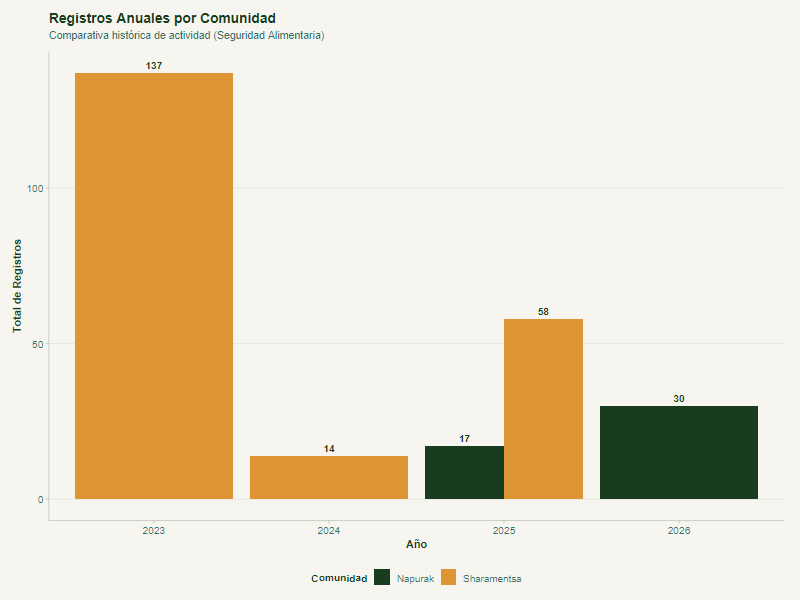

In [ ]:

# Aseguramos que el año se trate como una categoría (factor) para que el eje X sea limpio
serie_anual_alimentaria <- serie_anual_alimentaria %>%
  mutate(Anio_Label = format(Year, "%Y"))

ggplot(serie_anual_alimentaria, aes(x = Anio_Label, y = Total_registros, fill = Comunidad)) +
  # position = "dodge" crea las barras una al lado de la otra
  geom_col(position = position_dodge(width = 0.9)) +
  
  # Añadir el total sobre cada barra
  geom_text(aes(label = Total_registros), 
            position = position_dodge(width = 0.9), 
            vjust = -0.5,      # Ajuste vertical para que esté arriba de la barra
            size = 3.5, 
            fontface = "bold",
            color = PAL$hoja) +
  
  # Colores institucionales
  scale_fill_manual(values = PAL_CUAL) +
  
  labs(
    title = "Registros Anuales por Comunidad",
    subtitle = "Comparativa histórica de actividad (Seguridad Alimentaria)",
    x = "Año",
    y = "Total de Registros",
    fill = "Comunidad"
  ) +
  
  # Tu tema de la Fundación
  theme_pachamama() +
  theme(
    panel.grid.major.x = element_blank(), # Limpiamos el eje X para que se vea más moderno
    text = element_text(family = "sans")
  )

### Tasa de cambio anual

In [ ]:

tasa_cambio_df <- serie_anual_alimentaria %>%
  # Aseguramos el orden cronológico por comunidad
  arrange(Comunidad, Year) %>%
  group_by(Comunidad) %>%
  # Calculamos el total del año anterior
  mutate(Total_anterior = lag(Total_registros)) %>%
  # Calculamos la tasa (solo donde hay un año previo)
  mutate(Tasa_Cambio = ((Total_registros - Total_anterior) / Total_anterior) * 100) %>%
  # Filtramos para quedarnos solo con los registros que tienen cálculo
  filter(!is.na(Tasa_Cambio)) %>%
  mutate(Anio_Label = format(Year, "%Y"))

tasa_cambio_df

# A tibble: 3 × 6
# Groups:   Comunidad [2]
  Year       Comunidad   Total_registros Anio_Label Total_anterior Tasa_Cambio
  <date>     <chr>                 <int> <chr>               <int>       <dbl>
1 2026-01-01 Napurak                  30 2026                   17        76.5
2 2024-01-01 Sharamentsa              14 2024                  137       -89.8
3 2025-01-01 Sharamentsa              58 2025                   14       314. 

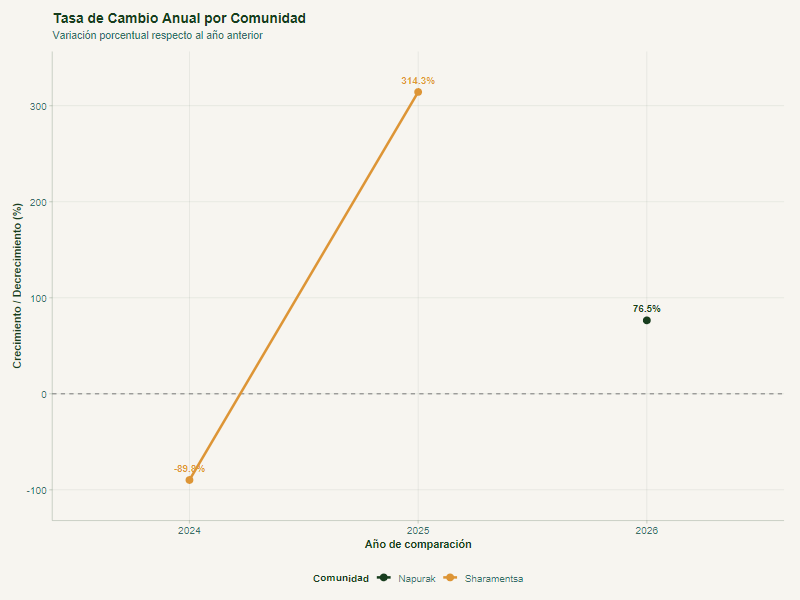

In [ ]:
ggplot(tasa_cambio_df, aes(x = Anio_Label, y = Tasa_Cambio, color = Comunidad, group = Comunidad)) +
  # Línea de referencia en 0%
  geom_hline(yintercept = 0, linetype = "dashed", color = "grey50") +
  
  geom_line(linewidth = 1.2) +
  geom_point(size = 3) +
  
  # Etiquetas de porcentaje sobre los puntos
  geom_text(aes(label = paste0(round(Tasa_Cambio, 1), "%")), 
            vjust = -1, size = 3.5, fontface = "bold", show.legend = FALSE) +
  
  scale_color_manual(values = PAL_CUAL) +
  
  labs(
    title = "Tasa de Cambio Anual por Comunidad",
    subtitle = "Variación porcentual respecto al año anterior",
    x = "Año de comparación",
    y = "Crecimiento / Decrecimiento (%)",
    color = "Comunidad"
  ) +
  
  # Ajuste de escala Y para dar espacio a las etiquetas
  expand_limits(y = c(min(tasa_cambio_df$Tasa_Cambio) - 20, max(tasa_cambio_df$Tasa_Cambio) + 20)) +
  
  theme_pachamama() +
  theme(text = element_text(family = "sans"))

### Descripción y obs actividades

In [ ]:
actividad_filtrada = seguridad_alimentaria_all%>%
  #filter(Actividad_monitorear == "Salud")%>% # se puede activar o desactivar el filtro
 # filter(Tipo_accion == "Entrega_de_insumos")%>%# se puede activar o desactivar el filtro
  select(Actividad_monitorear, Fecha, Tipo_accion, Descripcion_accion, observaciones,  Quien_dirigido, n_ninos, n_ninas, n_hombres, n_mujeres, Total_mujeres, Total_hombres, Total_beneficiarios)


actividad_filtrada

    Actividad_monitorear      Fecha Tipo_accion        Descripcion_accion observaciones Quien_dirigido n_ninos n_ninas n_hombres
1  Seguridad alimentaria 2023-01-01  Inspección  Verificación de Galpones                                   NA      NA        NA
2  Seguridad alimentaria 2023-01-01  Inspección  Verificacion de galpones                                   NA      NA        NA
3  Seguridad alimentaria 2023-01-01  Inspección  Verificacion de galpones                                   NA      NA        NA
4  Seguridad alimentaria 2023-01-01  Inspección  Verificacion de galpones                                   NA      NA        NA
5  Seguridad alimentaria 2023-01-01  Inspección  Verificacion de galpones                                   NA      NA        NA
6  Seguridad alimentaria 2023-01-01  Inspección  Verificacion de galpones                                   NA      NA        NA
7  Seguridad alimentaria 2023-01-01  Inspección  Verificacion de galpones                        

In [ ]:
stop_words_es <- data.frame(word = c("de", "la", "el", "en", "y", "a", "los", "las", "un", "una", 
                                     "con", "por", "para", "se", "del", "al", "lo", "su", "es", "una", "mas", "que"))

# 2. Procesamiento con limpieza de NAs
red_datos <- actividad_filtrada %>%
  filter(!is.na(observaciones)) %>%
  mutate(texto = str_to_lower(observaciones) %>% str_replace_all("[^[:alpha:][:space:]]", "")) %>%
  unnest_tokens(bigrama, texto, token = "ngrams", n = 2) %>%
  # Al separar, si una frase tenía una sola palabra, el segundo valor será NA
  separate(bigrama, c("p1", "p2"), sep = " ") %>%
  # ELIMINAR LOS NAs (Aquí es donde se soluciona el error)
  filter(!is.na(p1), !is.na(p2)) %>%
  # Quitar palabras sin significado
  filter(!p1 %in% stop_words_es$word, !p2 %in% stop_words_es$word) %>%
  count(p1, p2, sort = TRUE) %>%
  filter(n > 1)

# 3. Ahora sí, crear el objeto de red
red_objeto <- graph_from_data_frame(red_datos)
freq_nodos <- bind_rows(
  red_datos %>% select(word = p1, n),
  red_datos %>% select(word = p2, n)
) %>%
  group_by(word) %>%
  summarise(freq = sum(n), .groups = "drop")

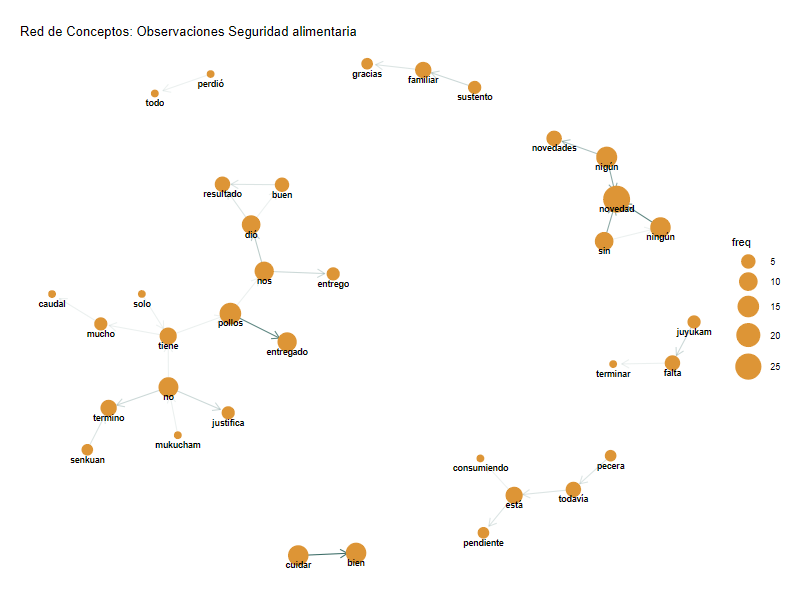

In [ ]:
# 4. Graficar
set.seed(123)
red_objeto <- graph_from_data_frame(red_datos)

V(red_objeto)$freq <- freq_nodos$freq[match(V(red_objeto)$name, freq_nodos$word)]


ggraph(red_objeto, layout = "kk") +
  geom_edge_link(
    aes(edge_alpha = n),
    edge_colour = PAL$rio,
    arrow = arrow(length = unit(3, "mm")),
    end_cap = circle(3, "mm"),
    show.legend = FALSE
  ) +
  geom_node_point(
    aes(size = freq),
    color = PAL$ave
  ) +
  geom_node_text(
    aes(label = name),
    vjust = 1.8,
    size = 3,
    fontface = "bold"
  ) +
  scale_size(range = c(3, 12)) +
  labs(
    title = "Red de Conceptos: Observaciones Seguridad alimentaria",
  ) +
  theme_void() +
  theme(plot.margin = margin(20, 20, 20, 20))

## Salud

In [ ]:
salud_df = planesv_df_0%>%filter(Actividad_monitorear == "Salud")

salud_df

     X      X_id                               X_uuid           X__version__
1  161 429928746 7475b0a6-c444-4fcb-b175-81f697f4d5bd vyBpPtWiys8ZVBrdkNPo5E
2  162 429929099 a83a84a8-4591-4868-a425-be9cc7489e49 vyBpPtWiys8ZVBrdkNPo5E
3  163 429929241 f1f2baff-bad1-48cf-a2ed-e80894ee6f44 vyBpPtWiys8ZVBrdkNPo5E
4  164 429929463 a35778cd-e69c-4933-bb20-9172c8abd735 vyBpPtWiys8ZVBrdkNPo5E
5  165 429929653 20dbba8a-e4d9-4f15-b7fd-ac9cbafe9efd vyBpPtWiys8ZVBrdkNPo5E
6  166 429932147 5a3ca941-839e-4ccb-8b22-42e45f1b04d0 vyBpPtWiys8ZVBrdkNPo5E
7  167 429932438 b21f90a3-0434-4b19-b8e0-8bc517a4af59 vyBpPtWiys8ZVBrdkNPo5E
8  168 429932645 89e0e868-df39-4926-9c61-89cff1e14ecd vyBpPtWiys8ZVBrdkNPo5E
9  169 429932724 dbb1ee51-6528-4142-9ca1-44de1b5e1b8d vyBpPtWiys8ZVBrdkNPo5E
10 170 429932786 920d9442-b432-4743-b68a-b4a5855b6987 vyBpPtWiys8ZVBrdkNPo5E
11 171 429932869 7f5f349a-41be-4d45-ad5e-fa26bb0fc964 vyBpPtWiys8ZVBrdkNPo5E
12 172 429932997 85b75549-6c7e-48af-aed6-e3376a03dbf3 vyBpPtWiys8ZVBrdkNPo5E

### Flujo de actividades

In [ ]:


# 1. Preparación y cálculo de beneficiarios
conteo_limpio <- salud_df %>%
  # Limpiar valores vacíos
  mutate(across(where(is.character), ~ ifelse(.x == "" | is.na(.x), "No definido", .x))) %>%
  # Asegurar que los conteos sean numéricos y tratar NAs como 0 para la suma
  mutate(across(c(n_ninos, n_ninas, n_hombres, n_mujeres), ~ replace_na(as.numeric(.x), 0))) %>%
  # Calcular el peso basado en beneficiarios
  mutate(Total_beneficiarios = n_ninos + n_ninas + n_hombres + n_mujeres)

# 2. Flujo A: Comunidad -> Tipo de Acción
flujo_A <- conteo_limpio %>%
  group_by(Comunidad, Tipo_accion) %>%
  summarise(Weight = sum(Total_beneficiarios, na.rm = TRUE), .groups = "drop") %>%
  rename(From = Comunidad, To = Tipo_accion)

# 3. Flujo B: Tipo de Acción -> A quién va dirigido
flujo_B <- conteo_limpio %>%
  group_by(Tipo_accion, Quien_dirigido) %>%
  summarise(Weight = sum(Total_beneficiarios, na.rm = TRUE), .groups = "drop") %>%
  rename(From = Tipo_accion, To = Quien_dirigido)

# 4. Unir flujos
datos_sankey_final <- bind_rows(flujo_A, flujo_B) %>%
  filter(Weight > 0) # Eliminar flujos de peso cero para evitar errores en el plot

# 5. Generar la visualización
colores_pacha_js <- paste0("['", paste(PAL_CUAL, collapse = "', '"), "']")

opts <- list(
  sankey = paste0("{
    node: { 
      colors: ", colores_pacha_js, ",
      label: { fontName: 'Arial', fontSize: 12, color: '", PAL$hoja, "' }
    },
    link: { colorMode: 'gradient', colors: ", colores_pacha_js, " }
  }")
)

sankey_plot <- gvisSankey(datos_sankey_final, 
                          from = "From", 
                          to = "To", 
                          weight = "Weight", 
                          options = opts)

plot(sankey_plot)

### Nube de palabras

In [ ]:

# 1. Definir Stop Words (palabras a excluir)
stop_words_es <- data.frame(word = c("de", "la", "el", "en", "y", "a", "los", "las", "un", "una", 
                                     "con", "por", "para", "se", "del", "al", "lo", "su", "es", 
                                     "entrega", "insumos", "accion", "descripcion"))

# 2. Tokenizar y contar frecuencias
conteo_palabras <- data.frame(texto = salud_df$Descripcion_accion) %>%
  mutate(texto = str_to_lower(texto) %>% str_replace_all("[^[:alpha:][:space:]]", "")) %>%
  unnest_tokens(word, texto) %>%
  filter(!word %in% stop_words_es$word) %>%
  count(word, sort = TRUE) %>%
  filter(nchar(word) > 2) # Evitar palabras de 1 o 2 letras

There were 14 warnings (use warnings() to see them)


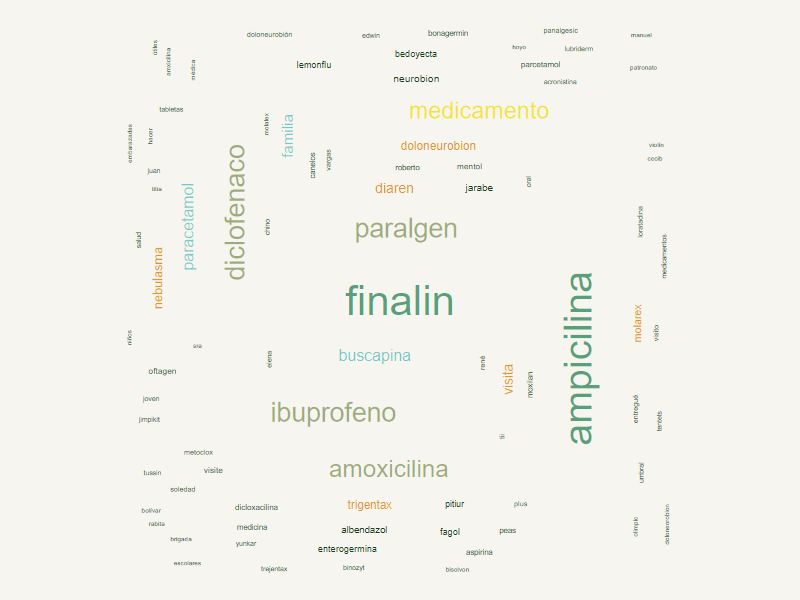

In [ ]:
# Configurar el área de dibujo
par(bg = PAL$fondo) # Usar el color de fondo de tu marca

wordcloud(
  words = conteo_palabras$word, 
  freq = conteo_palabras$n, 
  min.freq = 1,           # Mostrar incluso las que aparecen una vez
  max.words = 100,        # Limitar a las 100 más frecuentes para que sea legible
  random.order = FALSE,   # Las más grandes al centro
  rot.per = 0.35,         # 35% de palabras en vertical
  colors = as.character(PAL_CUAL),
  scale = c(3.5, 0.5),    # Ajustar tamaño máximo y mínimo de letra
  family = "sans"
)

In [ ]:
unique(planesv_df_0$Actividad_monitorear)

[1] "Seguridad alimentaria"  "Otro"                   "Salud"                  "Educación"              "Actividades economicas"

In [ ]:
salud_df = planesv_df_0%>%filter(Actividad_monitorear == "Otro")

salud_df

     X      X_id                               X_uuid           X__version__   X_submission_time X_validation_status  timestamp
1  137 429918977 0c06b516-faac-45ca-8a1d-4c2ac124cd70 vyBpPtWiys8ZVBrdkNPo5E 2025-01-14T21:46:42            Approved 1736893419
2  138 429919153 62a16503-7249-4c83-a493-2274e2342e71 vyBpPtWiys8ZVBrdkNPo5E 2025-01-14T21:47:29            Approved 1736893393
3  139 429919511 1546ad29-da89-41a8-a88c-6e673426ee61 vyBpPtWiys8ZVBrdkNPo5E 2025-01-14T21:49:36            Approved 1736893054
4  140 429919615 d27eae53-5722-4acb-99fe-6e0f45f21c90 vyBpPtWiys8ZVBrdkNPo5E 2025-01-14T21:50:24            Approved 1736893055
5  141 429920113 1a8b4974-85fb-4c09-9572-7ccea547a6f3 vyBpPtWiys8ZVBrdkNPo5E 2025-01-14T21:53:16            Approved 1736893059
6  142 429920419 f6ff5cf9-6797-4aa3-b10d-3fc37a1df152 vyBpPtWiys8ZVBrdkNPo5E 2025-01-14T21:54:33            Approved 1736893060
7  143 429920570 1c37e198-4344-4287-874c-730e120f4892 vyBpPtWiys8ZVBrdkNPo5E 2025-01-14T21:55:32        